# Notebook 2 - Data Preparation and Model Training

**What this notebook does:**
- Cleans the data
- Creates new features (Feature Engineering)
- Fixes class imbalance with SMOTE
- Trains and compares 3 ML models
- Saves the best model to disk

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, roc_auc_score, ConfusionMatrixDisplay
)
from imblearn.over_sampling import SMOTE

import os
os.makedirs('../models', exist_ok=True)

df = pd.read_csv('/Users/priyankakadam/Desktop/Projects/Predictive Maintenance/ai4i2020.csv')
print(f'Loaded: {df.shape[0]} rows, {df.shape[1]} columns')

Loaded: 10000 rows, 14 columns


## Step 2 - Clean the Data

**Why drop TWF, HDF, PWF, OSF, RNF?**

These are failure sub-types. They only exist WHEN a failure happens.
If we keep them, the model learns 'if TWF=1 then failure=1' - but in real life, we wouldn't know TWF until AFTER the machine broke. This is called **data leakage** - the model cheats using future information.

In [3]:
# Drop ID columns (no predictive value)
df.drop(columns=['UDI', 'Product ID'], inplace=True)

# Drop failure sub-types (data leakage risk)
failure_subtypes = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']
df.drop(columns=failure_subtypes, inplace=True)

print('Remaining columns:', df.columns.tolist())
print('Shape:', df.shape)

Remaining columns: ['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure']
Shape: (10000, 7)


## Step 3 - Encode the 'Type' Column
ML models only understand numbers. 'Type' has L, M, H (text).
We convert: L -> 0, M -> 1, H -> 2
This is called **Label Encoding**.

In [4]:
le = LabelEncoder()
df['Type'] = le.fit_transform(df['Type'])

print('Type encoding:', dict(zip(le.classes_, le.transform(le.classes_))))
df.head(3)

Type encoding: {'H': np.int64(0), 'L': np.int64(1), 'M': np.int64(2)}


,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure
0,2,298.1,308.6,1551,42.8,0,0
1,1,298.2,308.7,1408,46.3,3,0
2,1,298.1,308.5,1498,49.4,5,0


## Step 4 - Feature Engineering

We create 4 new columns from existing ones. These capture **physical relationships** that raw sensors don't show directly.

Feature engineering is one of the most valued skills in Data Science because it requires domain knowledge and creativity.

In [5]:
# 1. Temperature difference: high gap = possible overheating
df['temp_diff'] = df['Process temperature [K]'] - df['Air temperature [K]']

# 2. Power = Torque x Speed (physics formula - measures workload)
df['power'] = df['Torque [Nm]'] * df['Rotational speed [rpm]'] * (2 * np.pi / 60)

# 3. Worn tool under high stress = high failure risk
df['wear_torque'] = df['Tool wear [min]'] * df['Torque [Nm]']

# 4. How fast is the tool wearing relative to speed?
df['wear_rate'] = df['Tool wear [min]'] / (df['Rotational speed [rpm]'] + 1)

print('New features added! Total features:', df.shape[1] - 1)

# Check if new features correlate with failure
new_feats = ['temp_diff', 'power', 'wear_torque', 'wear_rate']
corr = df[new_feats + ['Machine failure']].corr()['Machine failure'].drop('Machine failure')
print('\nNew feature correlation with failure:')
print(corr.sort_values(ascending=False))

New features added! Total features: 10

New feature correlation with failure:
wear_torque    0.190427
power          0.176039
wear_rate      0.130194
temp_diff     -0.111676
Name: Machine failure, dtype: float64


## Step 5 - Separate Features and Target

- **X** = everything the model LEARNS FROM (sensor readings)
- **y** = what the model PREDICTS (failure yes/no)

In [6]:
X = df.drop(columns=['Machine failure'])  # features
y = df['Machine failure']                  # target

print('X shape:', X.shape)
print('y value counts:')
print(y.value_counts())

X shape: (10000, 10)
y value counts:
Machine failure
0    9661
1     339
Name: count, dtype: int64


## Step 6 - Train / Test Split

We split: **80% training**, **20% testing**.

The test set is data the model **NEVER sees during training**.
At the end, we test on it to simulate real-world performance.

`stratify=y` ensures both splits have the same 3.4% failure ratio.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,    # 20% for testing
    random_state=42,  # fixed seed - results are reproducible
    stratify=y        # keeps same class ratio in both splits
)

print(f'Training set:  {X_train.shape[0]} rows')
print(f'Test set:      {X_test.shape[0]} rows')
print(f'Training failure rate: {y_train.mean()*100:.1f}%')
print(f'Test failure rate:     {y_test.mean()*100:.1f}%')

Training set:  8000 rows
Test set:      2000 rows
Training failure rate: 3.4%
Test failure rate:     3.4%


## Step 7 - Fix Class Imbalance with SMOTE

Only 3.4% failures means the model will be lazy and predict 'no failure' always to get 96% accuracy.

**SMOTE** creates synthetic (realistic but artificial) failure examples to balance the training data.

**Important:** ONLY apply SMOTE to training data - never to test data!

In [8]:
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print('Before SMOTE:', dict(y_train.value_counts()))
print('After SMOTE: ', dict(pd.Series(y_train_bal).value_counts()))
print(f'Training set grew from {len(y_train)} to {len(y_train_bal)} rows')

Before SMOTE: {0: np.int64(7729), 1: np.int64(271)}
After SMOTE:  {0: np.int64(7729), 1: np.int64(7729)}
Training set grew from 8000 to 15458 rows


## Step 8 - Scale the Features

Different columns have very different ranges:
- Temperature: ~300
- RPM: ~1500
- Tool wear: 0-250

Without scaling, RPM would dominate just because its numbers are bigger.

`StandardScaler` transforms each column to have mean=0 and std=1.

**Rule:** Fit scaler on training data ONLY, then transform both sets.

In [9]:
scaler = StandardScaler()

# fit_transform: learns the mean/std from training AND scales it
X_train_scaled = scaler.fit_transform(X_train_bal)

# transform only: uses the same mean/std learned from training
X_test_scaled  = scaler.transform(X_test)

print('Scaling done!')
print(f'Air temp column - Mean: {X_train_scaled[:,1].mean():.2f} (should be ~0)')
print(f'Air temp column - Std:  {X_train_scaled[:,1].std():.2f}  (should be ~1)')

Scaling done!
Air temp column - Mean: 0.00 (should be ~0)
Air temp column - Std:  1.00  (should be ~1)


## Step 9 - Train 3 Models

We train three models from simple to complex:
1. **Logistic Regression** - simple, fast, good baseline
2. **Random Forest** - 100 decision trees voting together
3. **XGBoost** - trees built sequentially, each fixing the last one's mistakes

Comparing models shows you are systematic - a key quality for Data Scientists.

In [10]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost':             XGBClassifier(n_estimators=100, random_state=42,
                                          eval_metric='logloss', verbosity=0)
}

results = {}

for name, model in models.items():
    print(f'\n{"="*50}')
    print(f'Training: {name}...')

    # Train
    model.fit(X_train_scaled, y_train_bal)

    # Predict on test set (data the model has NOT seen)
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]  # probability of failure

    # Calculate metrics
    f1  = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob)

    results[name] = {'model': model, 'f1': f1, 'roc': roc,
                     'y_pred': y_pred, 'y_prob': y_prob}

    print(classification_report(y_test, y_pred, target_names=['No Failure', 'Failure']))
    print(f'ROC-AUC: {roc:.4f}')


Training: Logistic Regression...
              precision    recall  f1-score   support

  No Failure       0.99      0.86      0.92      1932
     Failure       0.18      0.87      0.30        68

    accuracy                           0.86      2000
   macro avg       0.59      0.86      0.61      2000
weighted avg       0.97      0.86      0.90      2000

ROC-AUC: 0.9272

Training: Random Forest...
              precision    recall  f1-score   support

  No Failure       0.99      0.98      0.99      1932
     Failure       0.67      0.85      0.75        68

    accuracy                           0.98      2000
   macro avg       0.83      0.92      0.87      2000
weighted avg       0.98      0.98      0.98      2000

ROC-AUC: 0.9846

Training: XGBoost...
              precision    recall  f1-score   support

  No Failure       0.99      0.98      0.99      1932
     Failure       0.66      0.85      0.74        68

    accuracy                           0.98      2000
   macro avg

## Step 10 - Compare Models Visually

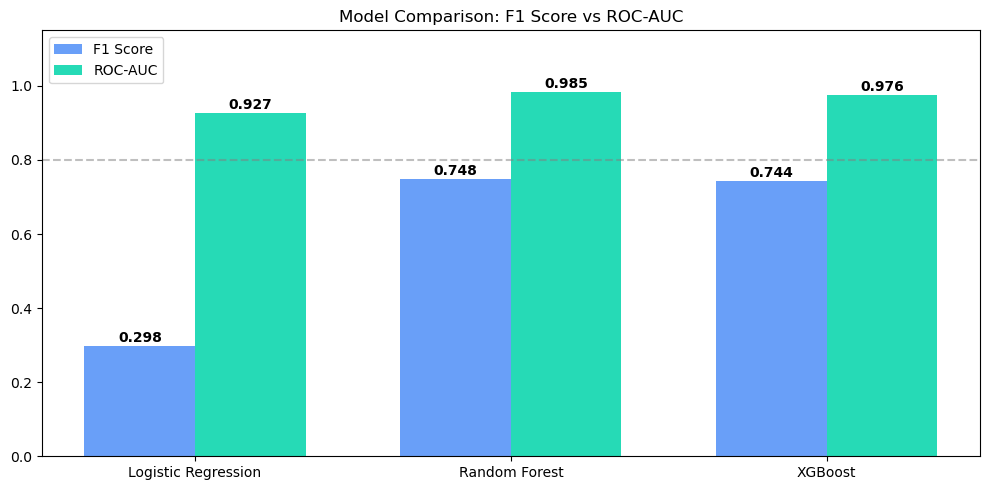

In [11]:
names = list(results.keys())
f1s   = [results[n]['f1']  for n in names]
rocs  = [results[n]['roc'] for n in names]

x = np.arange(len(names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, f1s,  width, label='F1 Score',  color='#4f8ef7', alpha=0.85)
bars2 = ax.bar(x + width/2, rocs, width, label='ROC-AUC',   color='#00d4aa', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(names)
ax.set_ylim(0, 1.15)
ax.set_title('Model Comparison: F1 Score vs ROC-AUC')
ax.legend()
ax.axhline(0.8, linestyle='--', color='gray', alpha=0.5)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', fontsize=10, fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

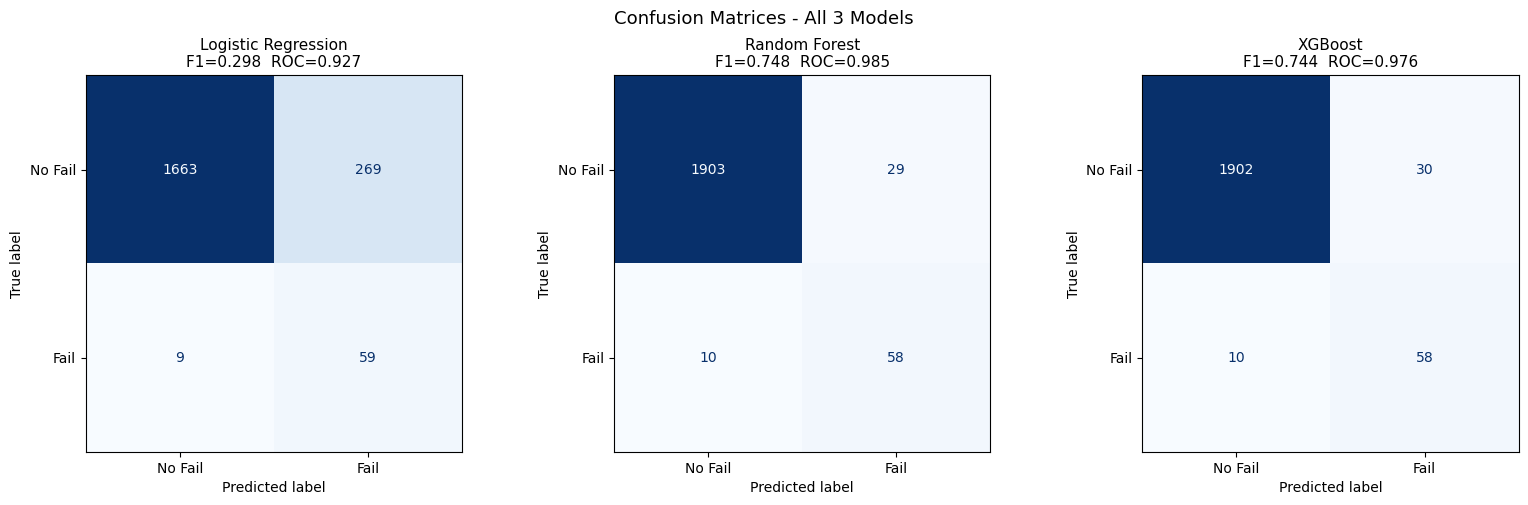

How to read confusion matrix:
  Top-left:  True Negatives  (correctly said NO failure)
  Top-right: False Positives (said failure but it was fine - false alarm)
  Bottom-left:  False Negatives (MISSED a real failure - most costly!)
  Bottom-right: True Positives  (correctly caught the failure)


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    disp = ConfusionMatrixDisplay(cm, display_labels=['No Fail', 'Fail'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f"{name}\nF1={res['f1']:.3f}  ROC={res['roc']:.3f}", fontsize=11)

plt.suptitle('Confusion Matrices - All 3 Models', fontsize=13)
plt.tight_layout()
plt.show()

print('How to read confusion matrix:')
print('  Top-left:  True Negatives  (correctly said NO failure)')
print('  Top-right: False Positives (said failure but it was fine - false alarm)')
print('  Bottom-left:  False Negatives (MISSED a real failure - most costly!)')
print('  Bottom-right: True Positives  (correctly caught the failure)')

## Step 11 - Feature Importance
Which sensors matter most to the XGBoost model?

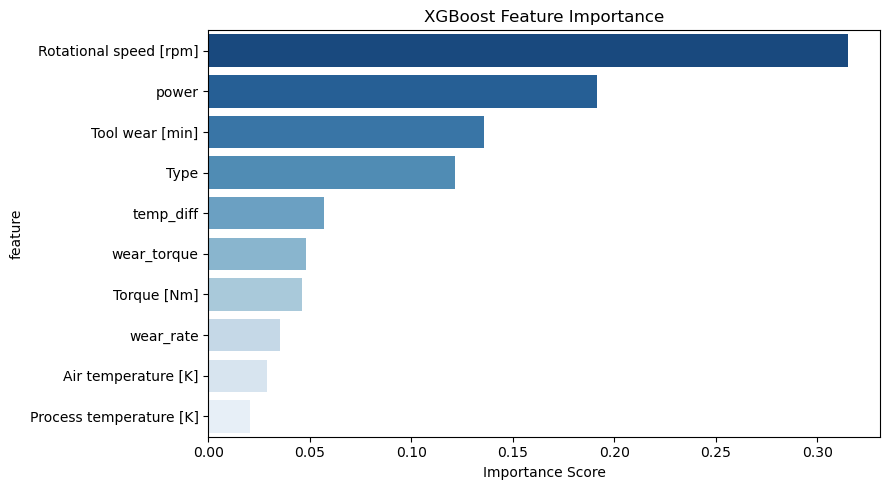

Top 5 features:
               feature  importance
Rotational speed [rpm]    0.315179
                 power    0.191316
       Tool wear [min]    0.135674
                  Type    0.121746
             temp_diff    0.056804


In [14]:
xgb = results['XGBoost']['model']
feature_names = X.columns.tolist()

imp_df = pd.DataFrame({
    'feature':    feature_names,
    'importance': xgb.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(9, 5))
sns.barplot(x='importance', y='feature', data=imp_df, palette='Blues_r')
plt.title('XGBoost Feature Importance')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print('Top 5 features:')
print(imp_df.head(5).to_string(index=False))

## Step 12 - Save Best Model

In [15]:
best_name  = max(results, key=lambda x: results[x]['f1'])
best_model = results[best_name]['model']

print(f'Best model: {best_name}')
print(f'  F1 Score: {results[best_name]["f1"]:.4f}')
print(f'  ROC-AUC:  {results[best_name]["roc"]:.4f}')

joblib.dump(best_model, '../models/best_model.pkl')
joblib.dump(scaler,     '../models/scaler.pkl')

print('\nSaved: ../models/best_model.pkl')
print('Saved: ../models/scaler.pkl')
print('\nNext: Run the Streamlit app with: streamlit run app/streamlit_app.py')

Best model: Random Forest
  F1 Score: 0.7484
  ROC-AUC:  0.9846

Saved: ../models/best_model.pkl
Saved: ../models/scaler.pkl

Next: Run the Streamlit app with: streamlit run app/streamlit_app.py
